---
title: "Figures: The Envelope Theorem and the Euler Equation"
execute:
  depends_on_env: [IC_EXEC_ENV]
---

Draws the figure in [The Envelope Theorem and the Euler Equation](#sec:Envelope). Run all the cells to redraw it into `figures/`; change the parameters to see how it responds.

Ported from Carroll's Mathematica, `Code/Mathematica/EnvelopeTheorem.m` in the [handout's source](https://www.econ2.jhu.edu/people/ccarroll/public/LectureNotes/Consumption/Envelope.zip). That code plots `v[m,c]` but defines the function as `vFunc`, so as shipped it draws only the dots; the curves here use `vFunc`, as the published figure does.

The consumer has CRRA utility $\mathrm{u}(c) = c^{1-\rho}/(1-\rho)$ and resources $m$ to divide between two periods, with no discounting and no interest:

$$\underline{\mathrm{v}}(m, c) = \mathrm{u}(c) + \mathrm{u}(m - c).$$

For each $m$, the curve plots $\underline{\mathrm{v}}(m, c)$ against $c$, and the dot marks its maximum, at $c = m/2$. The dots trace out $\mathrm{v}(m)$.

In [ ]:
# Run anywhere: install the book's package (it brings econ-ark, numpy and matplotlib) if it
# is missing. Inside the book's own environment this does nothing.
try:
    import intertemporal_choice
except ImportError:
    %pip install -q git+https://github.com/intertemporal-choice/intertemporal-choice.github.io

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from intertemporal_choice import style

style.use_book_style()

In [ ]:
rho = 2.0                                   # relative risk aversion
m_values = np.arange(4.0, 6.0 + 1e-9, 0.2)  # resources: one curve for each
half_width = 0.5                            # each curve spans c = m/2 +/- 0.5


def u(c):
    return c ** (1 - rho) / (1 - rho)


def v_underline(m, c):
    return u(c) + u(m - c)

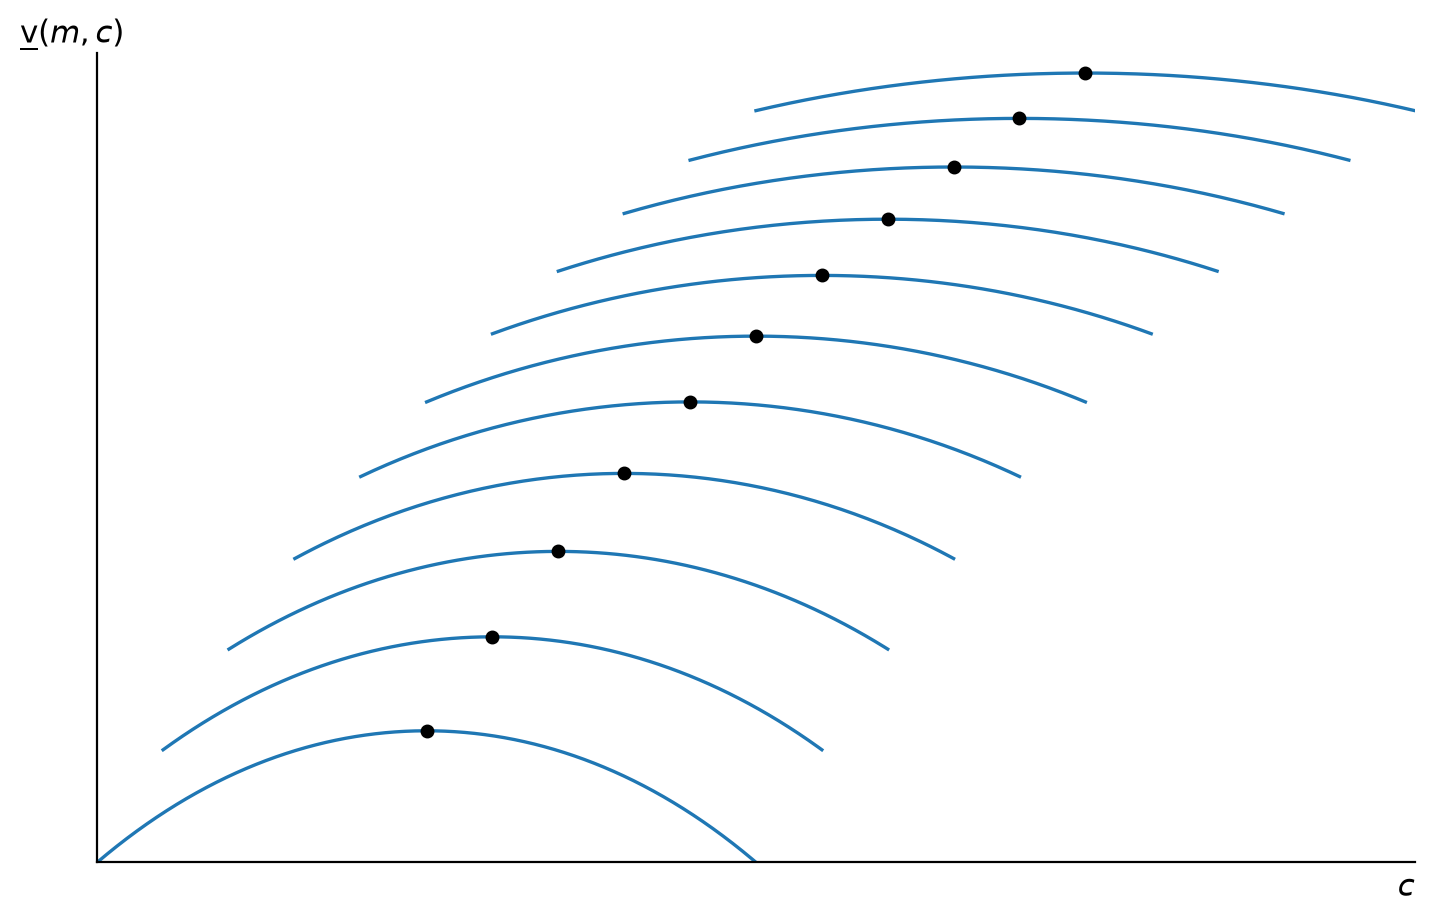

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 8.5 / 1.618))
for m in m_values:
    c = np.linspace(m / 2 - half_width, m / 2 + half_width, 200)
    ax.plot(c, v_underline(m, c), color="C0", linewidth=1.2)
    ax.plot(m / 2, v_underline(m, m / 2), "o", color="black", markersize=4)

m_min, m_max = m_values[0], m_values[-1]
ax.set_xlim(m_min / 2 - half_width, m_max / 2 + half_width)
ax.set_ylim(v_underline(m_min, m_min / 2 - half_width), v_underline(m_max, m_max / 2) + 0.01)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel(r"$c$", loc="right")
ax.set_ylabel(r"$\underline{\mathrm{v}}(m, c)$", loc="top", rotation=0, labelpad=-10)
style.save(fig, "Envelope")